# Missing Data Analysis

This notebook analyzes and visualizes missing data patterns in the stroke dataset. We'll examine the mechanisms of missingness (MCAR vs MAR) and create diagnostic visualizations.

## 1. Import Required Libraries and Load Data

Import necessary libraries for data manipulation, visualization, and missing data analysis. Configure display options and load the preprocessed stroke dataset.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [18]:
# Load dữ liệu đã hợp nhất từ bước trước
# File này là output của bước Data Fusion
try:
    df = pd.read_csv('../data/processed/stroke_all.csv')
    print("✅ Đã load dữ liệu thành công!")
    print(f"   Shape: {df.shape}")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file '../data/processed/stroke_all.csv'. Hãy chạy bước Fusion trước.")

✅ Đã load dữ liệu thành công!
   Shape: (60091, 12)


## 2. Quantify Missing Data Ratios

Create a function to calculate and report the count and percentage of missing values for each column. Identify columns with missing data and highlight special cases like 'Unknown' values in smoking_status.

In [19]:
def report_missing(df):
    """Tính toán và báo cáo tỷ lệ missing data"""
    # Đếm số lượng null thực sự (NaN)
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    
    # Tạo bảng báo cáo
    report = pd.DataFrame({
        'Total Missing': missing,
        '% Missing': missing_percent
    })
    
    # Lọc ra các cột có dữ liệu thiếu > 0
    report = report[report['Total Missing'] > 0].sort_values(by='% Missing', ascending=False)
    
    display(report)
    
    # Kiểm tra thêm giá trị "Unknown" trong smoking_status
    if 'smoking_status' in df.columns:
        unknown_count = (df['smoking_status'] == 'Unknown').sum()
        unknown_pct = (unknown_count / len(df)) * 100
        print(f"\n⚠️ Lưu ý đặc biệt: Cột 'smoking_status' có {unknown_count} giá trị là 'Unknown' ({unknown_pct:.2f}%).")
        print("   Trong ngữ cảnh y tế, 'Unknown' có thể coi là một dạng Missing Data (MNAR).")

report_missing(df)

,Total Missing,% Missing
bmi,2701,4.494849



⚠️ Lưu ý đặc biệt: Cột 'smoking_status' có 15568 giá trị là 'Unknown' (25.91%).
   Trong ngữ cảnh y tế, 'Unknown' có thể coi là một dạng Missing Data (MNAR).


## 3. Visualize Missing Data Patterns

Use the missingno library to create matrix and heatmap visualizations. Generate a matrix plot to identify missing data locations and a correlation heatmap to explore relationships between missing values across columns.

<Figure size 1000x600 with 0 Axes>

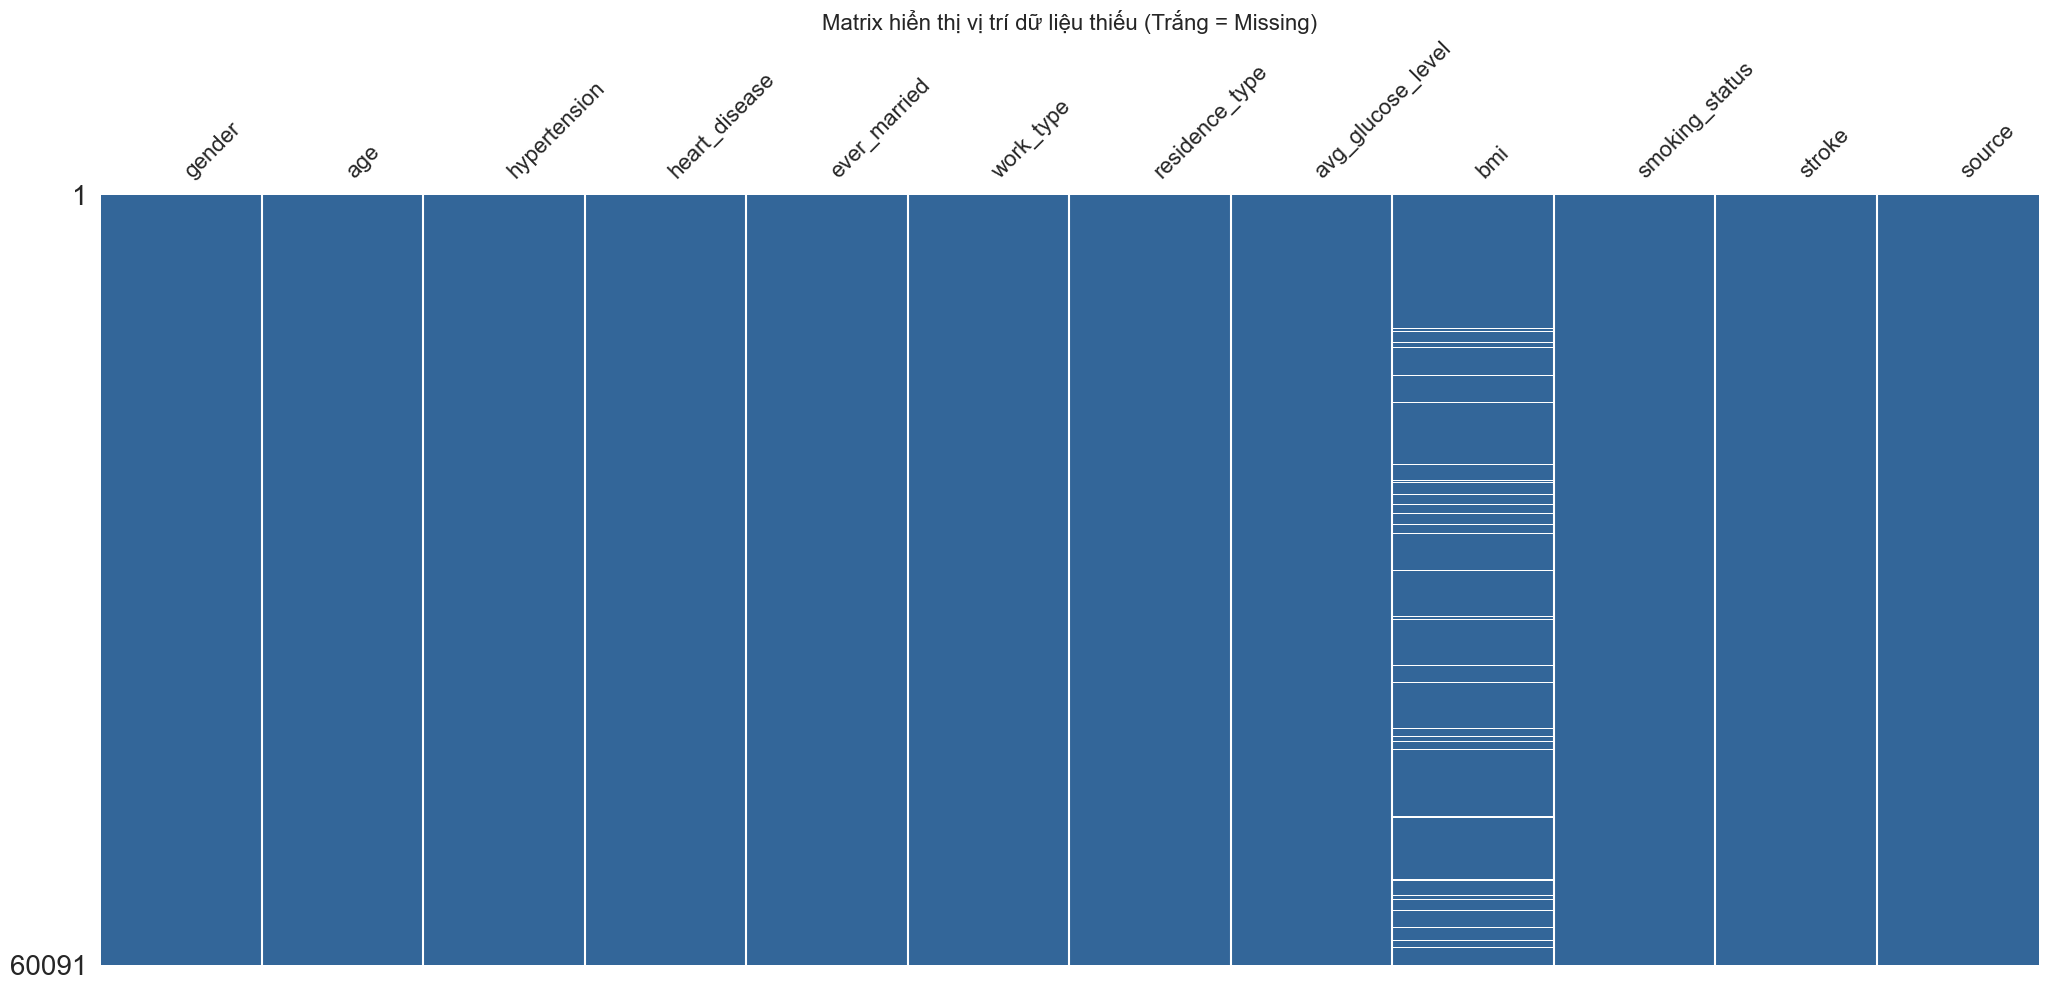

In [20]:
# 3.1 Matrix Plot - Xem vị trí khuyết thiếu
# Giúp nhận diện xem dữ liệu thiếu tập trung ở đâu hay rải rác
plt.figure(figsize=(10, 6))
msno.matrix(df, sparkline=False, color=(0.2, 0.4, 0.6))
plt.title("Matrix hiển thị vị trí dữ liệu thiếu (Trắng = Missing)", fontsize=16)
plt.show()

**There is only "bmi" data is missing**

## 4. Diagnose Missing Data Mechanisms (MCAR vs MAR)

Analyze whether missing data is Missing Completely At Random (MCAR) or Missing At Random (MAR) by examining relationships between missing BMI and other variables like age and stroke status. Create visualizations and calculate statistics to determine if missingness depends on observed variables.

In [21]:
# Tạo biến tạm thời: 1 là thiếu BMI, 0 là có BMI
df['bmi_missing_flag'] = df['bmi'].isnull().astype(int)

### 4.1 Analyze Relationship with Age

Check if missing BMI data is associated with age differences. This helps determine if missingness is related to observed variables (MAR) or completely random (MCAR).

C:\Users\Admin\AppData\Local\Temp\ipykernel_23712\1882608204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bmi_missing_flag', y='age', data=df, palette='Set2')


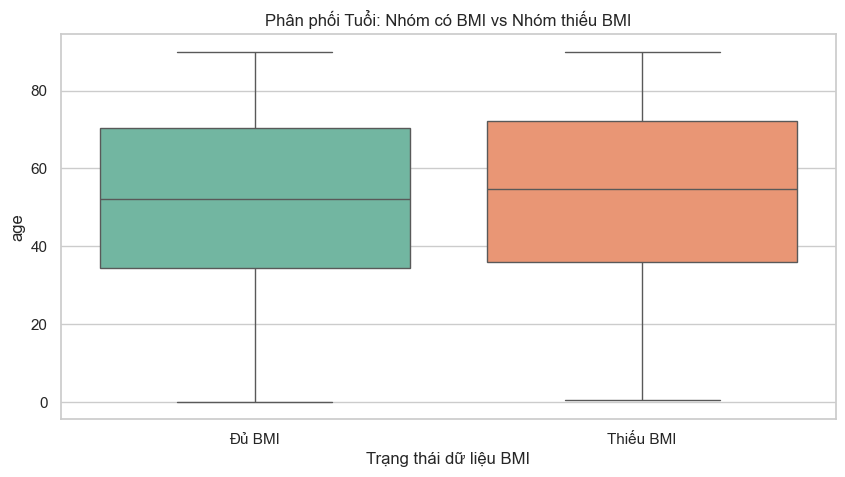

- Tuổi trung bình nhóm THIẾU BMI: 54.05
- Tuổi trung bình nhóm ĐỦ BMI:    52.14
- Chênh lệch: 1.91 tuổi
=> NHẬN XÉT: Tuổi không ảnh hưởng nhiều. Có thể là MCAR (Missing Completely At Random).


In [22]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='bmi_missing_flag', y='age', data=df, palette='Set2')
plt.title("Phân phối Tuổi: Nhóm có BMI vs Nhóm thiếu BMI")
plt.xticks([0, 1], ['Đủ BMI', 'Thiếu BMI'])
plt.xlabel("Trạng thái dữ liệu BMI")
plt.show()

# Tính toán cụ thể
avg_age_missing = df[df['bmi_missing_flag'] == 1]['age'].mean()
avg_age_present = df[df['bmi_missing_flag'] == 0]['age'].mean()

print(f"- Tuổi trung bình nhóm THIẾU BMI: {avg_age_missing:.2f}")
print(f"- Tuổi trung bình nhóm ĐỦ BMI:    {avg_age_present:.2f}")
print(f"- Chênh lệch: {abs(avg_age_missing - avg_age_present):.2f} tuổi")

if abs(avg_age_missing - avg_age_present) > 5:
    print("=> NHẬN XÉT: Có sự chênh lệch đáng kể về tuổi. Dữ liệu có thể là MAR (Missing At Random).")
    print("   Nghĩa là: Người lớn tuổi (hoặc trẻ tuổi) có xu hướng bị thiếu dữ liệu BMI cao hơn.")
else:
    print("=> NHẬN XÉT: Tuổi không ảnh hưởng nhiều. Có thể là MCAR (Missing Completely At Random).")

### 4.2 Analyze Relationship with Stroke Status

Examine if patients with stroke have different rates of missing BMI data. This analysis helps determine if missingness is related to the target variable.

In [23]:
# Kiểm tra mối liên hệ với TARGET (Stroke)
# Liệu người bị đột quỵ thì hồ sơ hay bị thiếu BMI hơn?
cross_tab = pd.crosstab(df['stroke'], df['bmi_missing_flag'], normalize='index')
print("\nTỷ lệ thiếu BMI theo nhóm Đột quỵ (0: Không, 1: Có):")
display(cross_tab)


Tỷ lệ thiếu BMI theo nhóm Đột quỵ (0: Không, 1: Có):


bmi_missing_flag,0,1
stroke,,
0,0.955184,0.044816
1,0.952462,0.047538


### 4.3 Clean Up Temporary Flag

Remove the temporary flag column used for analysis.

In [24]:
# Clean up cột tạm
df.drop(columns=['bmi_missing_flag'], inplace=True)